# 중고차 가격 예측을 위한 데이터 전처리 파이프라인
- Target: price

- Strategy: 완전 관측 데이터(Complete-case) 기반 비례 층화 추출 및 스케일링/인코딩

## 라이브러리 로드 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 원본 파일 불러오기
file_path = 'vehicles.csv'


if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"원본 데이터 로드 완료! 데이터 크기: {df.shape}")
else:
    print("파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")
    print(f"입력한 경로: {file_path}")


print(f"원본 데이터 크기: {df.shape}")

원본 데이터 로드 완료! 데이터 크기: (426880, 26)
원본 데이터 크기: (426880, 26)


## Step 1. 불필요한 피처 제거

In [2]:
# 1. 가격 예측에 불필요하거나 신뢰할 수 없는 Feature 제거
columns_to_drop = [
    'id', 'url', 'image_url',                 # 고유 식별자 및 URL
    'region', 'region_url', 'lat', 'long', 'state', # 위치 정보
    'county',                                 # 100% 결측치
    'size',                                    # 80% 결측치 및 실제 사이트에 없는 임의로 추가된 데이터
    'description'                           # 주관적 견해가 들어간 비정형 데이터
]

df_step1 = df.drop(columns=columns_to_drop, errors='ignore')
print(f"열 제거 후 데이터 크기: {df_step1.shape}")

열 제거 후 데이터 크기: (426880, 15)


## Step 2. 결측치 행 전부 제거

In [3]:
# 2. 결측치가 하나라도 포함된 레코드(행) 전부 제거
# (빈칸이 없는 완벽하게 깨끗한 데이터만 남김)
df_step2 = df_step1.dropna()

print(f"결측치 행 전체 제거 후 데이터 크기: {df_step2.shape}")

결측치 행 전체 제거 후 데이터 크기: (61005, 15)


## Step 3. 이상치 제거 - Outlier Detection

In [4]:
# 3. 도메인 지식을 활용한 이상치 필터링
# 판매 글 작성 기준 연식이 20년 초과인 차량 제외
# posting_date를 datetime으로 변환
df_step2['posting_date'] = pd.to_datetime(df_step2['posting_date'], utc=True)

# 게시 연도 추출
posting_year = df_step2['posting_date'].dt.year

# 조건 생성
condition_price = (
    (df_step2['price'] >= 1000) &
    (df_step2['price'] <= 1000000)
)

condition_odometer = (
    df_step2['odometer'] <= 300000
)

# 게시 연도 기준 20년 이상 된 차량 제거
condition_year = (
    df_step2['year'] >= (posting_year - 20)
)

# 필터링
df_step3 = df_step2[
    condition_price &
    condition_odometer &
    condition_year
].copy()

print(f"이상치 필터링 후 데이터 크기: {df_step3.shape}")

이상치 필터링 후 데이터 크기: (54805, 15)


## Step 4. 파생 변수 생성(vehicle_age)

In [5]:
# 4. 차량 나이(Vehicle Age) 변수 생성 및 year 제거
# posting_date를 활용하여 차량 연식(Age) 계산

# 시계열 데이터 처리
df_step3['posting_date'] = pd.to_datetime(df_step3['posting_date'], utc=True)

df_step3['vehicle_age'] = df_step3['posting_date'].dt.year - df_step3['year']

# posting_date, year는 vehicle_age와 다중공선성을 가지므로 모델에서 제거
df_step4 = df_step3.drop(columns=['posting_date', 'year'])

print("파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)")
display(df_step4[['vehicle_age', 'price', 'odometer']].head(3))

파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)


,vehicle_age,price,odometer
32,9.0,27990,68696.0
33,5.0,34590,29499.0
35,5.0,29990,17302.0


## Step 5. VIN 전처리

In [6]:
# 5. VIN 전처리
# 알파벳을 전부 대문자로 바꾼 후 대문자와 숫자 조합(I, O, Q 제외)의 17자인지 확인
df_step4['VIN'] = (
    df_step4['VIN']
    .astype(str)
    .str.strip()
    .str.upper()
)

# VIN 조건 생성
condition_vin = df_step4['VIN'].str.fullmatch(
    r'[A-HJ-NPR-Z0-9]{17}',
    na=False
)

# 조건 만족하는 행만 유지
df_step5 = df_step4[condition_vin].copy()

print(f"VIN 필터링 후 데이터 크기: {df_step5.shape}")

VIN 필터링 후 데이터 크기: (54690, 14)


## Step 6. model 문자열 정제

In [7]:
# 6. model 피처 문자열 정제 (f-150, F150 등 불일치 해결)
# 문자열을 모두 소문자로 바꾸고, 정규표현식을 사용해 알파벳과 숫자 외의 모든 문자(공백, 하이픈 등) 제거

df_step5['model_clean'] = df_step5['model'].astype(str).str.lower().apply(lambda x: re.sub(r'[^a-z0-9]', '', x))

# 정제 전후 고유값 개수 비교 확인
original_unique = df_step5['model'].nunique()
clean_unique = df_step5['model_clean'].nunique()

# 기존 model 열을 정제된 열로 교체
df_step5['model'] = df_step5['model_clean']
df_step5.drop(columns=['model_clean'], inplace=True)

print(f"model 문자열 정제 완료! 고유 모델 종류: {original_unique:,}개 -> {clean_unique:,}개")

model 문자열 정제 완료! 고유 모델 종류: 5,780개 -> 5,407개


## 10,000개 랜덤 샘플링

In [8]:
df_sample = df_step5.sample(n=10000, random_state=42)

df_sample.to_csv(
    'preprocessed_used_cars_sample_10000.csv',
    index=False,
    encoding='utf-8-sig'
)

## VIN Feature Creation 이후 데이터 로드

In [9]:
# 원본 파일 불러오기
new_file_path = 'vehicles_msrp.csv'


if os.path.exists(new_file_path):
    df_new = pd.read_csv(new_file_path)
    print(f"원본 데이터 로드 완료! 데이터 크기: {df_new.shape}")
else:
    print("파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")
    print(f"입력한 경로: {new_file_path}")


print(f"원본 데이터 크기: {df_new.shape}")

원본 데이터 로드 완료! 데이터 크기: (7192, 15)
원본 데이터 크기: (7192, 15)


## Step 7. 비례 층화 추출을 통한 샘플링
- 전처리 5,000개로 샘플링


In [10]:
# 7. 타겟 변수(price) 분위수 분할 기반 층화 샘플링 (목표: 5,000개)
SAMPLE_SIZE = 5000

# 5개의 분위수로 가격대 분할 (Equal Frequency Binning)
df_new['price_tier'] = pd.qcut(df_new['price'], q=5, labels=['Tier1', 'Tier2', 'Tier3', 'Tier4', 'Tier5'])

# 각 Tier(구간)에서 균등하게 추출하여 총 5,000개 샘플링
df_sampled = df_new.groupby('price_tier', group_keys=False).apply(
    lambda x: x.sample(n=int(SAMPLE_SIZE/5), random_state=42)
).copy()

# 샘플링 완료 후 필요 없는 임시 변수 삭제
#df_sampled.drop(columns=['price_tier'], inplace=True)

# 인덱스 초기화
df_sampled.reset_index(drop=True, inplace=True)

print(f"비례 층화 샘플링 완료! 최종 학습용 데이터 크기: {df_sampled.shape}")

비례 층화 샘플링 완료! 최종 학습용 데이터 크기: (5000, 15)


## Step 8. 범주형 변수 인코딩

In [11]:
# 8. 범주형 데이터 인코딩 (Label & One-Hot Encoding)

# [1] Label Encoding: 서열이 있는 condition
cond_map = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}
df_sampled['condition'] = df_sampled['condition'].map(cond_map)

# [2] 기통 수(cylinders) 숫자 추출
# "8 cylinders" -> 8 로 수치만 추출
extracted_cylinders = df_sampled['cylinders'].astype(str).str.extract(r'(\d+)')[0]
# 숫자가 없는 경우(전기차, 로터리 엔진 등 원래 'other'였던 데이터)는 'other'로 보존
df_sampled['cylinders'] = extracted_cylinders.fillna('other')


# [3] 누적 점유율 및 최소 빈도 기반 그룹화, 원-핫 인코딩 시 피쳐가 너무 많이 생기는 점을 해결하기 위함
# 각 피처별로 'other'의 비율이 15%를 넘지 않도록
# 최소 1% 이상의 점유율을 가지거나, 누적 점유율이 85%가 될 때까지만 카테고리를 살림
def smart_grouping(series, min_freq=0.01, max_cumulative=0.85):
    # 각 카테고리별 점유율(%) 계산 및 내림차순 정렬
    frequencies = series.value_counts(normalize=True)

    valid_categories = []
    cumulative_sum = 0

    for cat, freq in frequencies.items():
        # 점유율이 너무 낮을 때(예: 1% 미만)
        if freq < min_freq:
            break

        valid_categories.append(cat)
        cumulative_sum += freq

        # 살려둔 카테고리들의 누적 점유율이 85%를 넘어가면 멈춤
        if cumulative_sum >= max_cumulative:
            break

    # 살아남은 카테고리 외에는 전부 'other'로 변환
    return series.apply(lambda x: x if x in valid_categories else 'other')

# 차원 축소 대상 피처들에 스마트 그룹화 적용
grouping_cols = ['manufacturer', 'paint_color', 'type']

for col in grouping_cols:
    df_sampled[col] = smart_grouping(df_sampled[col])

    # Other의 최종 비율이 얼마나 되는지 출력해서 확인
    other_ratio = (df_sampled[col] == 'other').mean() * 100
    print(f"[{col}] 피처의 'other' 비율 통제 결과: {other_ratio:.1f}%")

# [4] One-Hot Encoding: 서열이 없는 범주형 변수들
cols_to_ohe = ['cylinders', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'drive', 'paint_color']
df_encoded = pd.get_dummies(df_sampled, columns=cols_to_ohe, drop_first=True, dtype=int)

# VIN은 모델 학습용이 아니므로 임시 분리 (나중에 원본 추적용)
df_final = df_encoded.drop(columns=['VIN'], errors='ignore')

print(f"분할 전 기본 인코딩 완료! (현재 피처 개수: {df_final.shape[1]}개)")


[manufacturer] 피처의 'other' 비율 통제 결과: 14.0%
[paint_color] 피처의 'other' 비율 통제 결과: 8.1%
[type] 피처의 'other' 비율 통제 결과: 19.4%
분할 전 기본 인코딩 완료! (현재 피처 개수: 51개)


## Step 9. 수치형 데이터 스케일링

In [12]:
# 9. Data Leakage를 막기 위해 데이터 분할
# X(독립변수, 피처)와 y(종속변수, 정답) 분리
X = df_final.drop(columns=['price'])
y = df_final['price']

# 8:2 비율로 Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 타겟 변수(Price) 우측 편향 정규화를 위한 Log 변환 (log1p)
# 추후 예측이 끝나면 np.expm1()을 씌워 원래 달러 가격으로 복원해야함
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"Train / Test 분할 및 Target 변수 Log 변환 완료!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Train / Test 분할 및 Target 변수 Log 변환 완료!
X_train: (4000, 50), X_test: (1000, 50)


## Step 10. 타켓 인코딩

In [13]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# 10. 과적합 및 누수를 막기 위해 Target Encoding (category_encoders 활용)
import category_encoders as ce

# 1. TargetEncoder 객체 생성
# smoothing=10: 데이터 수가 적은 모델의 경우 과적합을 줄이기 위해 전체 평균값을 일부 반영
target_encoder = ce.TargetEncoder(cols=['model'], smoothing=10)

# 2. X_train에는 fit_transform을 적용하여 기준(Train 정답지)을 학습하고 변환
X_train['model_encoded'] = target_encoder.fit_transform(X_train['model'], y_train_log)

# 3. X_test에는 transform만 적용 (Leakage 차단)
X_test['model_encoded'] = target_encoder.transform(X_test['model'])

# 사용이 끝난 원본 텍스트 열 삭제
X_train.drop(columns=['model'], inplace=True)
X_test.drop(columns=['model'], inplace=True)

print("Smoothing 적용된 Target Encoding 완료!")

Smoothing 적용된 Target Encoding 완료!


## Step 11. 수치형 스케일링

In [15]:
# 11. 수치형 변수 StandardScaler 적용
scaler = StandardScaler()

# 스케일링 대상 피처 지정
num_cols = ['odometer', 'vehicle_age', 'model_encoded']

# X_train에는 fit_transform(기준점 잡기+변환), X_test에는 transform(변환)만 적용
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("모든 전처리 파이프라인 완벽 종료! 모델링 준비 끝")
print("\n[최종 X_train 데이터 프리뷰]")
display(X_train.head(3))

모든 전처리 파이프라인 완벽 종료! 모델링 준비 끝

[최종 X_train 데이터 프리뷰]


,condition,odometer,vehicle_age,estimate_msrp,cylinders_12,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,...,title_status_salvage,drive_fwd,drive_rwd,paint_color_blue,paint_color_grey,paint_color_other,paint_color_red,paint_color_silver,paint_color_white,model_encoded
4227,3,-1.059487,-1.575580,41000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0.385961
4676,2,-0.894214,-1.103460,49300.0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0.801004
800,3,1.071017,1.493195,27500.0,0,0,0,0,1,0,...,0,0,1,0,0,1,0,0,0,-0.315107


## 중간 데이터셋 뽑기

In [16]:
# vehicles_v2 = 'vehicles_v2.csv'
# df_step4.to_csv(vehicles_v2, index=False)

# 전처리 완료 데이터 EDA (사후 검증 시각화)

In [17]:
# 시각화 테마 설정
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.unicode_minus'] = False

# 시각화를 위해 X_train과 y_train_log를 임시로 병합 (분석용)
df_eda = X_train.copy()
df_eda['price_log'] = y_train_log

print("EDA용 통합 데이터프레임 준비 완료")

EDA용 통합 데이터프레임 준비 완료


## 1. 로그 변환된 타겟 변수 분포 확인

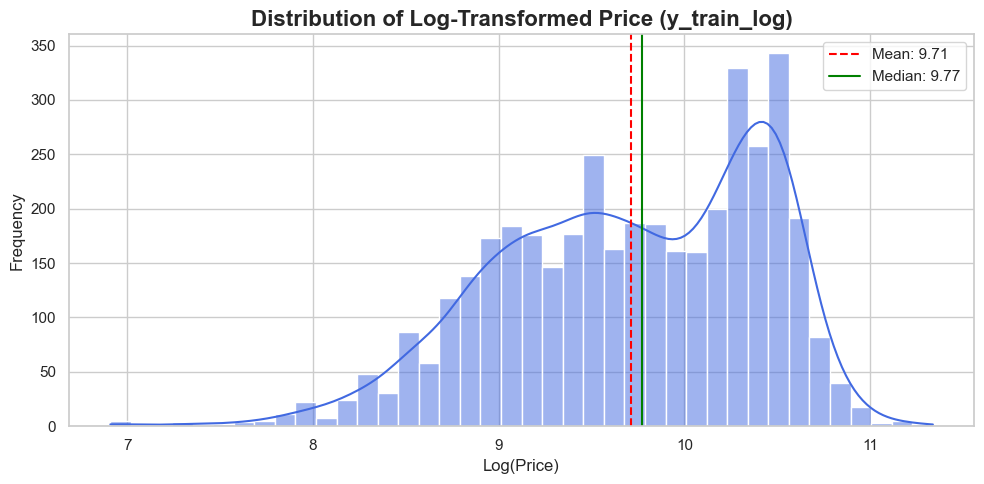

In [18]:
# 1. 정답지(Target) 분포 검증

plt.figure(figsize=(10, 5))
sns.histplot(df_eda['price_log'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Log-Transformed Price (y_train_log)", fontsize=16, fontweight='bold')
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# 평균과 중앙값 표시
plt.axvline(df_eda['price_log'].mean(), color='red', linestyle='--', label=f"Mean: {df_eda['price_log'].mean():.2f}")
plt.axvline(df_eda['price_log'].median(), color='green', linestyle='-', label=f"Median: {df_eda['price_log'].median():.2f}")

plt.legend()
plt.tight_layout()
plt.show()

#### Distribution of Log-Transformed Price (y_train_log) 그래프 해석

**기대 이유(효과)**  
보통의 중고차 가격 그래프는 중간 가격대가 가장 많고 일부의 고가 차량으로 인해 오른쪽 꼬리가 긴 형태의 그래프가 나옴.  
이러한 문제를 로그 변환을 통해 분포를 더 안정적으로 만들고 모델 학습 성능을 개선하고자 했음.

---

**결과 해석**  
분포가 한쪽으로 심하게 치우치지 않고 비교적 완만해짐.  

평균 = 9.71, 중앙값 = 9.77로 둘이 매우 가까움.  
→ 데이터가 극단적으로 치우쳐 있지 않다.  
→ 로그 변환이 왜도를 줄이는 데 효과적이었다는 해석이 가능해짐.

두 개의 봉우리는 저가 차량 그룹과 고가 차량 그룹이 어느 정도 나뉘어져있을 가능성이 있음.

## 2. StandardScaler 적용 결과 확인

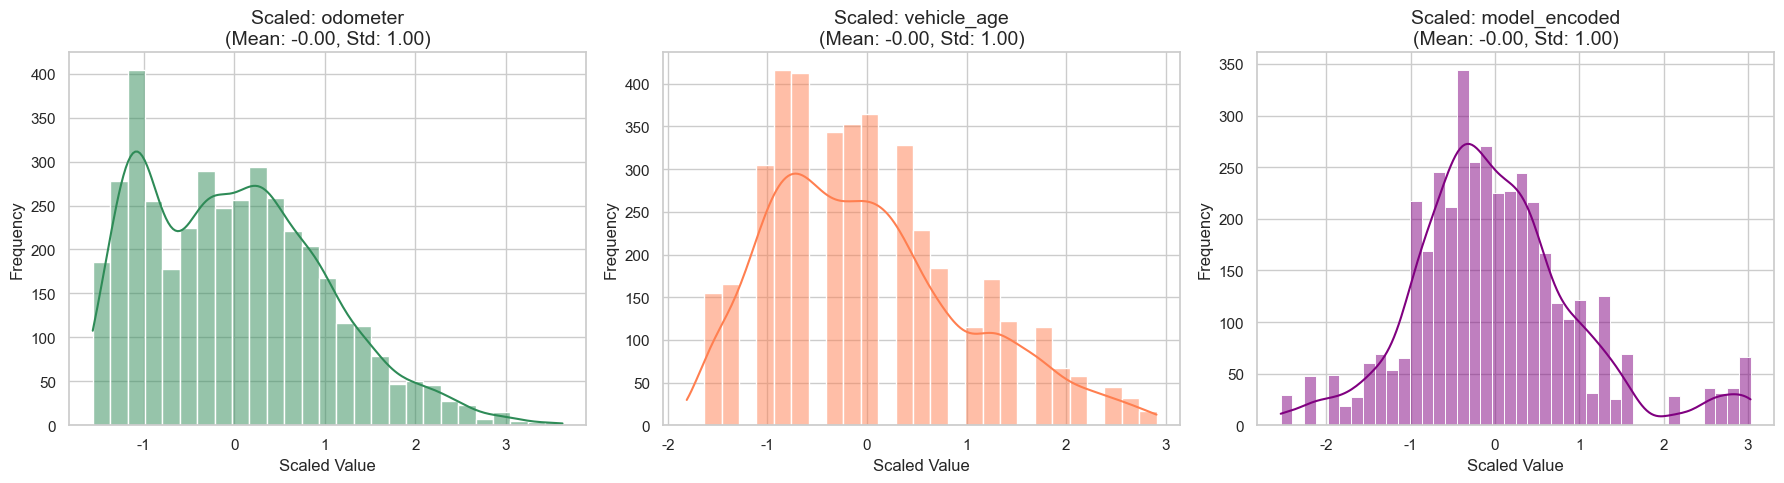

In [19]:
# 2. 스케일링된 수치형 변수 분포 검증
# -> 평균이 0, 표준편차가 1 근처로 잘 모였는지 확인

scaled_cols = ['odometer', 'vehicle_age', 'model_encoded']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['seagreen', 'coral', 'purple']

for i, col in enumerate(scaled_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f"Scaled: {col}\n(Mean: {df_eda[col].mean():.2f}, Std: {df_eda[col].std():.2f})", fontsize=14)
    axes[i].set_xlabel("Scaled Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Scaled odometer, vehicle_age, model_encoded 그래프 해석

**기대 이유(효과)**  
각 feature별 값의 범위가 다름 → 특정 feature의 영향이 지나치게 커지거나 학습 속도가 느려질 수 있음 → Standard Scaling 적용.

---

**결과 해석**  
모든 그래프가 목표한 대로 변환 후 평균은 0, 표준편차는 1에 가까운 값을 보임.

**- odometer**  
일부 고주행 차량(이상치 여부는 추가 확인 필요)으로 인해 오른쪽 꼬리가 긴 형태를 보이지만, 전체적으로 안정적인 분포로 정규화되었음.

**- vehicle_age**  
연식이 정수값(이산형 변수)이므로 중간중간 비는 값이 존재함.  
비교적 부드러운 종 모양을 가지지만 오른쪽 꼬리가 약간 존재함 → 오래된 차량 일부가 포함되어 있음을 의미.

**- model_encoded**  
model_encoded는 Target Encoding을 적용한 변수임.  
각 차량 모델이 평균 가격 기반의 연속적인 값으로 변환되었기 때문에 scaling 이후 세 변수 중 정규분포에 가장 가까운 형태를 나타냄.

## 3. Target Encoding의 위력 확인 - 회귀선 산점도

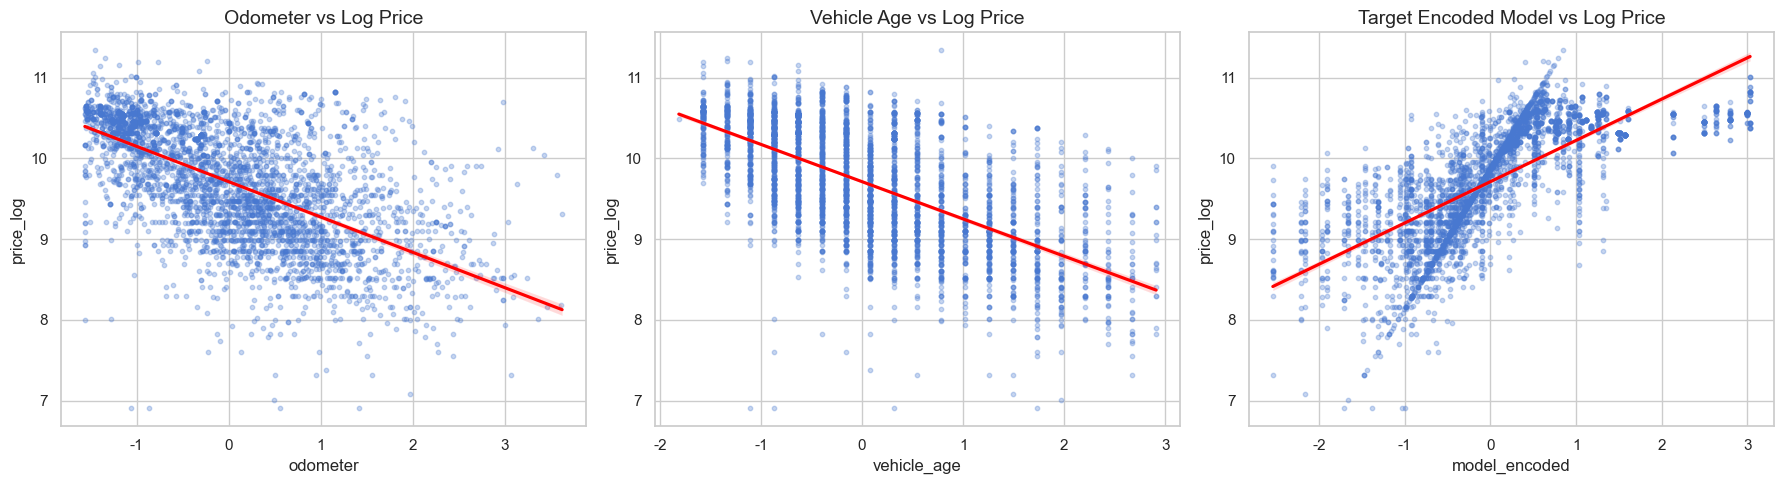

In [20]:
# 3. 주요 수치형/인코딩 변수와 가격(Log)의 관계

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3-1. 주행거리 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='odometer', y='price_log', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title("Odometer vs Log Price", fontsize=14)

# 3-2. 차량 나이 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='vehicle_age', y='price_log', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title("Vehicle Age vs Log Price", fontsize=14)

# 3-3. 모델 인코딩 값 vs 가격 (강한 양의 상관관계 기대!)
sns.regplot(data=df_eda, x='model_encoded', y='price_log', ax=axes[2],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[2].set_title("Target Encoded Model vs Log Price", fontsize=14)

plt.tight_layout()
plt.show()


#### Scatter plot 그래프 해석

**기대 이유(효과)**  
feature와 가격 간 관계 확인, 선형 관계 존재 여부 확인, 회귀 모델에 유의미한 변수인지 검증을 위함.  
regression line(빨간 선)을 통해 양의 상관관계(+)인지 음의 상관관계(-)인지, 관계 강도를 시각적으로 확인 가능함.

---

**결과 해석**

**- odometer vs log price**  
회귀선을 통해 음의 상관관계 가짐을 알 수 있음 → 현실적인 패턴(주행거리가 길수록 가격이 떨어짐)을 따름.  
브랜드, 연식 등에 따라 가격에 영향을 받을 수 있기 때문에 완벽한 직선은 아님.

**- vehicle_age vs log price**  
역시 회귀선을 통해 음의 상관관계 가짐을 알 수 있음 → 현실적인 패턴(연식이 오래될수록 가격이 떨어짐)을 따름.  
vehicle_age는 정수값(이산형 변수)이므로 점이 세로로 나타남.

**- target encoded model vs log price**  
회귀선을 통해 양의 상관관계를 가짐을 알 수 있음.  
model을 가격 기준으로 target encoding 했기 때문에 가격과 양의 상관관계를 가짐.

다만, 회귀선은 모든 점에 대한 최적의 직선을 찾기 때문에 중앙의 점들이 급상승하는 듯이 보이는 부분과는 차이가 있어 보일 수 있음.

## 4. 모델을 위한 핵심 상관관계 히트맵 - Top 15 피처

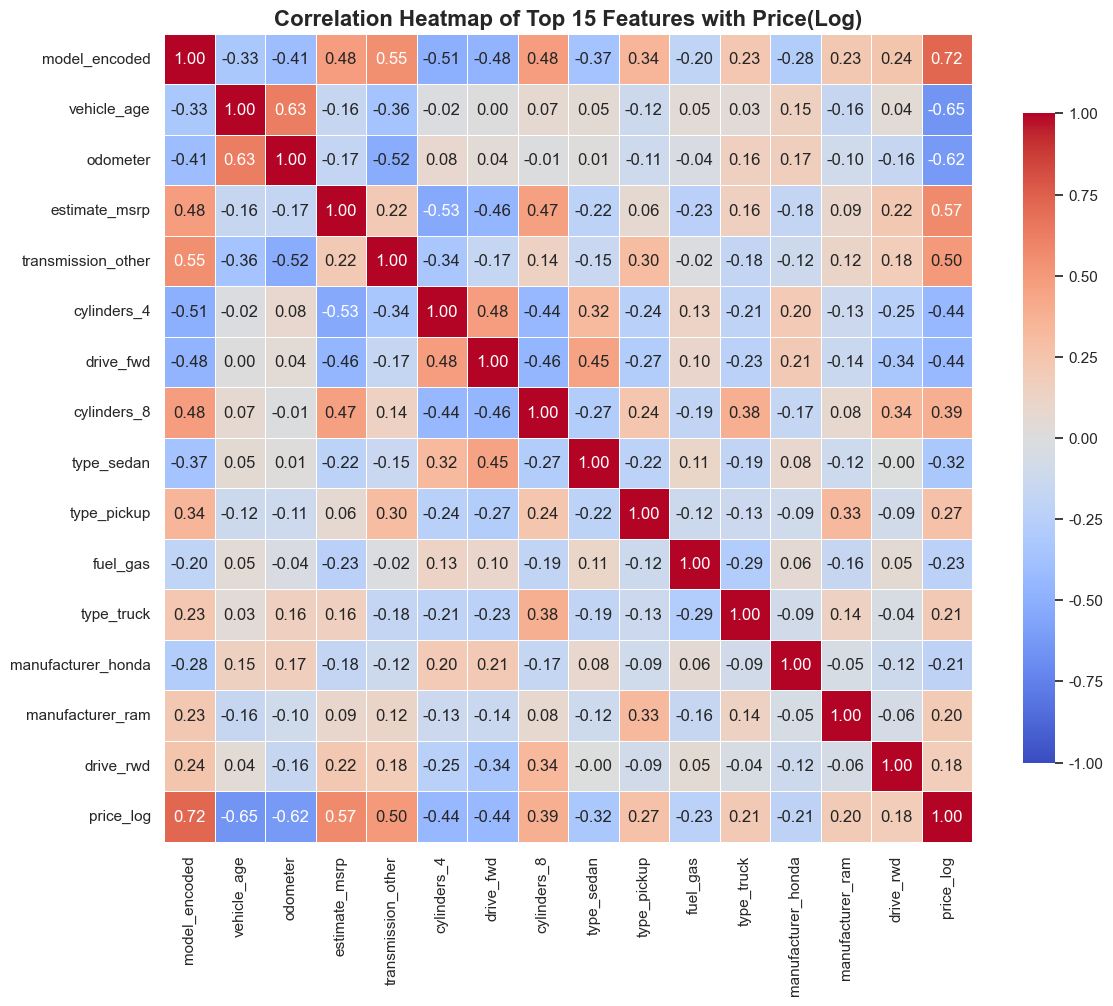

In [21]:
# 4. 타겟(price_log)과 가장 상관관계가 높은 Top 15 피처 추출 및 히트맵

# 타겟 변수와의 상관계수 계산 (절댓값 기준 내림차순)
correlations = df_eda.corr()['price_log'].abs().sort_values(ascending=False)

# 자기 자신(price_log)을 제외한 Top 15 피처 선정
top_15_features = correlations.index[1:16]

# Top 15 피처 + 타겟 변수로 상관관계 행렬 생성
top_corr_matrix = df_eda[top_15_features.tolist() + ['price_log']].corr()

plt.figure(figsize=(12, 10))
# 시각화
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Top 15 Features with Price(Log)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()